<a href="https://colab.research.google.com/github/elangbijak4/Swarm-Humanoid-Control-PoC/blob/main/Implementation_code1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Stability Index (Swarm): 0.2697
Stability Index (Centralized): 0.4981


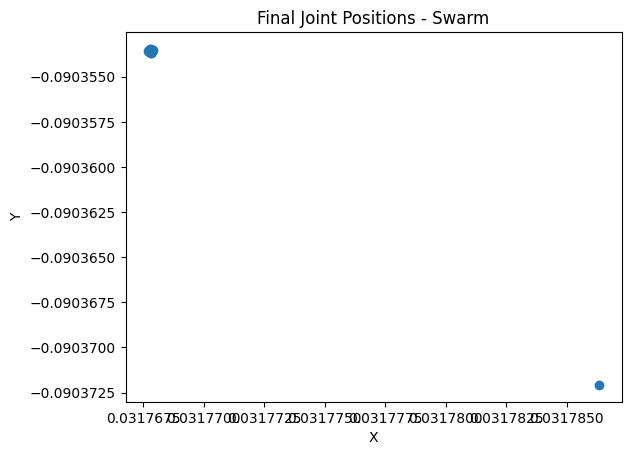

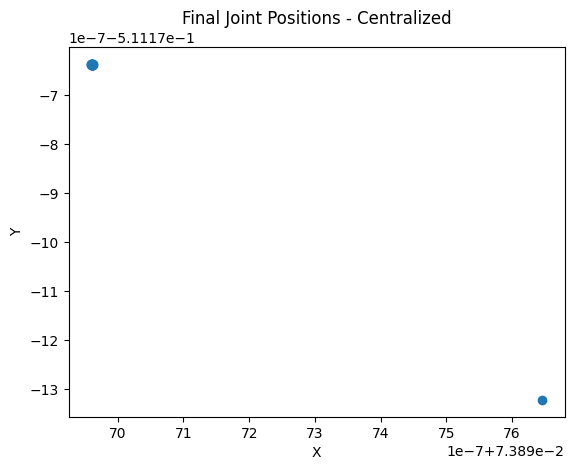

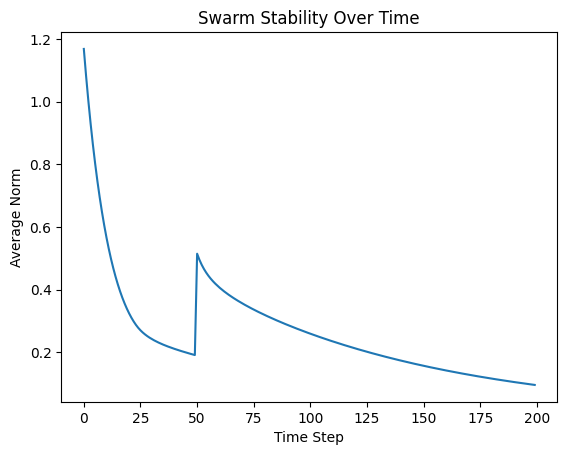

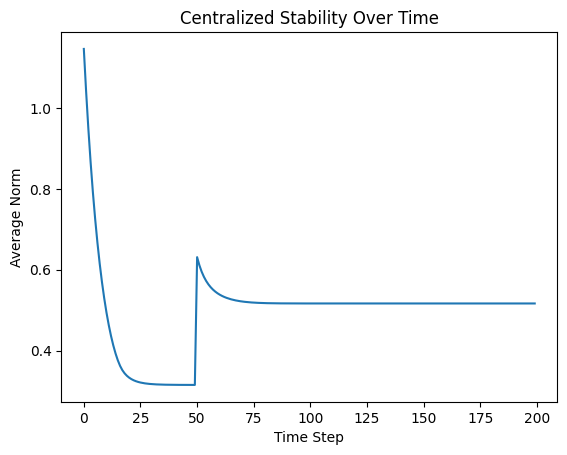

Proposed Rule Hash: 486020e7029070368b17 ...
Approval Ratio: 0.85
Rule Update Accepted.


In [1]:
# Swarm-Based Humanoid Joint Coordination (2D Proof of Concept)
# Author: PoC aligned with distributed swarm-based architecture
# Note: No rigid-body physics. Pure swarm-rule based coordination.

import numpy as np
import matplotlib.pyplot as plt
import hashlib
import random

np.random.seed(42)

# ----------------------------
# 1. Configuration
# ----------------------------

N = 20                 # number of joint-agents
T = 200                # simulation steps
alpha = 0.05           # alignment weight
beta = 0.02            # cohesion weight
gamma = 0.01           # stability weight
consensus_threshold = 0.7  # 70% approval needed

# Initial 2D state of joints (random scatter)
states_swarm = np.random.randn(N, 2)
states_central = states_swarm.copy()

# ----------------------------
# 2. Swarm Update Function
# ----------------------------

def swarm_update(states, alpha, beta, gamma):
    new_states = states.copy()
    global_mean = np.mean(states, axis=0)

    for i in range(N):
        alignment = np.mean(states - states[i], axis=0)
        cohesion = global_mean - states[i]
        stability = -states[i]

        update = alpha * alignment + beta * cohesion + gamma * stability
        new_states[i] += update

    return new_states

# ----------------------------
# 3. Centralized Baseline
# ----------------------------

def centralized_update(states):
    global_mean = np.mean(states, axis=0)
    return states + 0.1 * (global_mean - states)

# ----------------------------
# 4. Simulation
# ----------------------------

swarm_history = []
central_history = []

for t in range(T):
    if t == 50:
        # Disturb one joint
        states_swarm[0] += np.array([5.0, -5.0])
        states_central[0] += np.array([5.0, -5.0])

    states_swarm = swarm_update(states_swarm, alpha, beta, gamma)
    states_central = centralized_update(states_central)

    swarm_history.append(states_swarm.copy())
    central_history.append(states_central.copy())

swarm_history = np.array(swarm_history)
central_history = np.array(central_history)

# ----------------------------
# 5. Stability Index
# ----------------------------

def stability_index(history):
    return np.mean(np.linalg.norm(history, axis=2))

SI_swarm = stability_index(swarm_history)
SI_central = stability_index(central_history)

print("Stability Index (Swarm):", round(SI_swarm, 4))
print("Stability Index (Centralized):", round(SI_central, 4))

# ----------------------------
# 6. Plot Final State (Swarm)
# ----------------------------

plt.figure()
plt.scatter(swarm_history[-1,:,0], swarm_history[-1,:,1])
plt.title("Final Joint Positions - Swarm")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# ----------------------------
# 7. Plot Final State (Centralized)
# ----------------------------

plt.figure()
plt.scatter(central_history[-1,:,0], central_history[-1,:,1])
plt.title("Final Joint Positions - Centralized")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# ----------------------------
# 8. Stability Over Time
# ----------------------------

swarm_stability_time = [np.mean(np.linalg.norm(swarm_history[t], axis=1)) for t in range(T)]
central_stability_time = [np.mean(np.linalg.norm(central_history[t], axis=1)) for t in range(T)]

plt.figure()
plt.plot(swarm_stability_time)
plt.title("Swarm Stability Over Time")
plt.xlabel("Time Step")
plt.ylabel("Average Norm")
plt.show()

plt.figure()
plt.plot(central_stability_time)
plt.title("Centralized Stability Over Time")
plt.xlabel("Time Step")
plt.ylabel("Average Norm")
plt.show()

# ----------------------------
# 9. Secure Rule Evolution Demo
# ----------------------------

def hash_parameters(alpha, beta, gamma):
    param_string = f"{alpha}-{beta}-{gamma}"
    return hashlib.sha256(param_string.encode()).hexdigest()

# Propose new parameters
proposed_alpha = 0.08
proposed_beta = 0.03
proposed_gamma = 0.02

proposal_hash = hash_parameters(proposed_alpha, proposed_beta, proposed_gamma)

# Simulate distributed voting
votes = [random.random() > 0.2 for _ in range(N)]  # 80% approval tendency
approval_ratio = sum(votes) / N

print("Proposed Rule Hash:", proposal_hash[:20], "...")
print("Approval Ratio:", round(approval_ratio, 2))

if approval_ratio >= consensus_threshold:
    alpha, beta, gamma = proposed_alpha, proposed_beta, proposed_gamma
    print("Rule Update Accepted.")
else:
    print("Rule Update Rejected.")
